## **Langevin Dynamics Visualization**

1. Define a probability distribution consisting of **two Gaussian peaks** and compute the **score function** using the gradient of the log probability.
2. Initialize a **starting point (walker)** far from the peaks.
3. Run **Langevin dynamics for 100 steps**, updating the position using the score (direction toward higher probability) plus Gaussian noise.
4. Store each step to record the **trajectory of the walker**.
5. Plot the **density contour (mountains)** of the distribution and overlay the **walker’s path** to visualize how it moves toward high-probability regions.

**Note:** Both peaks have the **same height** because they use the same variance (`σ = 0.8`) and equal weighting.

# Imports

In [40]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Defining Probability and Score Function

In [41]:
def get_log_prob(x):
    mu1 = torch.tensor([-2.0, -2.0])
    mu2 = torch.tensor([2.0, 2.0])
    sigma = 0.8
    p1 = torch.exp(-((x - mu1) ** 2).sum() / (2 * sigma**2))
    p2 = torch.exp(-((x - mu2) ** 2).sum() / (2 * sigma**2))
    return torch.log(p1 + p2 + 1e-8)

def get_score(x):
    x = x.clone().detach().requires_grad_(True)
    logp = get_log_prob(x)
    logp.backward()
    return x.grad

# Parameters

In [42]:
n_steps = 100
eta = 0.01
noise_scale = np.sqrt(2 * eta)

# Initializing the walker

In [43]:
current_pos = torch.tensor([0.0, -4.0], dtype=torch.float32)
path = [current_pos.clone().numpy()]
torch.manual_seed(42)

# Langevin Dynamics loop

In [44]:
for i in range(n_steps):
    score = get_score(current_pos)
    noise = torch.randn_like(current_pos)
    current_pos = current_pos + (eta * score) + (noise_scale * noise)
    path.append(current_pos.clone().numpy())

In [45]:
path = np.array(path)

# Creating background Grid

In [46]:
x_grid = np.linspace(-5, 5, 100)
y_grid = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z = np.zeros_like(X)

for i in range(100):
    for j in range(100):
        pt = torch.tensor([X[i, j], Y[i, j]])
        Z[i, j] = torch.exp(get_log_prob(pt)).item()

# Visualizing

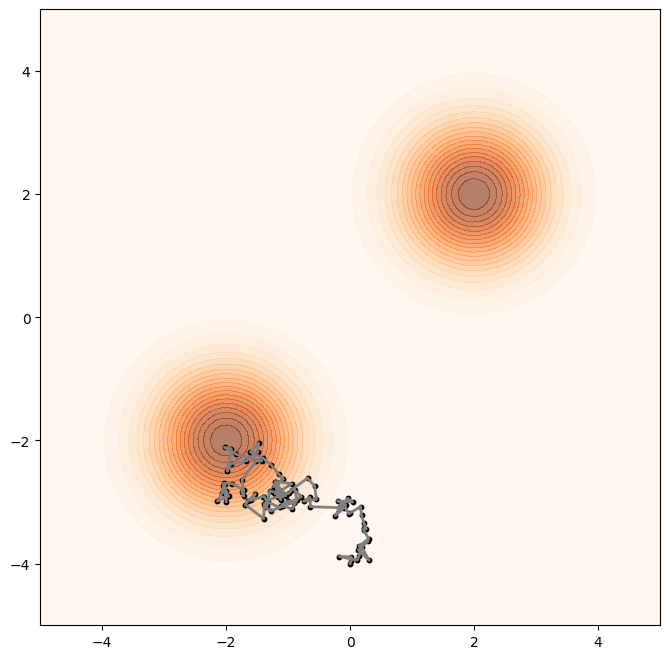

In [47]:
plt.figure(figsize=(8,8))
plt.contourf(X, Y, Z, levels=20, cmap="Oranges", alpha=0.6)
plt.plot(path[:,0], path[:,1], color="gray", linewidth=2)
plt.scatter(path[:,0], path[:,1], color="black", s=10)
plt.show()